# Ontario Hotel Performance Analysis (2020-2023)
## Executive Summary

This notebook conducts a comprehensive Exploratory Data Analysis (EDA) on the Ontario hotel industry, evaluating its performance through the extreme volatility of the global COVID-19 pandemic and its subsequent recovery.

**Primary Objectives:**
1. Clean and transform publicly available raw datasets into a machine-readable schema.
2. Quantify the loss and recovery velocity of Occupancy Rates across sub-regions.
3. Analyze the interplay between pricing power (Average Daily Rate) and volume (Occupancy).
4. Evaluate absolute revenue metrics (Revenue Per Available Room) to identify top-tier geographic assets.

---

### Step 1: Data Ingestion & Preprocessing
The raw data comes in a human-readable Excel format containing aggregated summary rows, spacer columns, and unstructured headers. We will programmatically flatten this structure, cast types, and exclude province-level aggregates to prevent duplicated metrics.

In [57]:
import pandas as pd

dfall = pd.read_excel("Project excel sheet.xlsx")
d1=pd.ExcelFile("Project excel sheet.xlsx")
df1= pd.read_excel("Project excel sheet.xlsx", sheet_name="2020-2023")

df1.columns = [
    'drop', 'Region',
    'Occ_2023', 'Occ_2022', 'Occ_2021', 'Occ_2020', 'drop2',
    'ADR_2023', 'ADR_2022', 'ADR_2021', 'ADR_2020', 'drop3',
    'RevPAR_2023', 'RevPAR_2022', 'RevPAR_2021', 'RevPAR_2020'
]
df1 = df1.drop(columns=['drop', 'drop2', 'drop3'])
df1 = df1.dropna(subset=['Region'])
df1 = df1[~df1['Region'].astype(str).str.contains('Hotel Statistics|Occupancy|Average|Revenue|2023|2022|2021|2020|Source|http', na=False)]

df1 = df1.reset_index(drop=True)

occ_cols = ['Occ_2023', 'Occ_2022', 'Occ_2021', 'Occ_2020']
df1[occ_cols] = df1[occ_cols].apply(pd.to_numeric, errors='coerce') * 100

# Step 5 — Convert ADR and RevPAR to numeric
other_cols = ['ADR_2023', 'ADR_2022', 'ADR_2021', 'ADR_2020',
              'RevPAR_2023', 'RevPAR_2022', 'RevPAR_2021', 'RevPAR_2020']
df1[other_cols] = df1[other_cols].apply(pd.to_numeric, errors='coerce').round(2)

df1[occ_cols] = df1[occ_cols].round(2)

df1['Region'] = df1['Region'].str.strip()

df1['Region'] = df1['Region'].str.replace('Kitchener/Waterloo/          Cambridge/Guelph', 'Kitchener/Waterloo/Cambridge/Guelph')



print(df1.head(10))
print(df1.dtypes)




                  Region  Occ_2023  Occ_2022  Occ_2021  Occ_2020  ADR_2023  \
0                ONTARIO     68.07     62.83     44.11     34.79    198.72   
1   Greater Toronto Area     73.57     67.17     43.86     31.81    227.55   
2       Downtown Toronto     70.32     63.09     30.68     21.91    323.82   
3        Toronto Airport     79.97     73.59     48.74     34.39    192.14   
4               GTA West     74.29     67.17     47.30     36.24    168.93   
5        GTA  East/North     73.45     69.40     56.64     40.88    169.13   
6        Eastern Ontario     61.08     58.43     47.52     40.33    155.22   
7               Kingston     62.80     56.00     44.17     35.21    172.03   
8  Other Eastern Ontario     60.42     59.47     49.13     42.60    148.54   
9                 Ottawa     68.54     61.41     41.01     35.72    196.15   

   ADR_2022  ADR_2021  ADR_2020  RevPAR_2023  RevPAR_2022  RevPAR_2021  \
0    179.57    128.79    126.03       135.26       112.82        56

### Step 2: COVID-19 Resilience & Recovery Velocity

The pandemic created an unprecedented structural break in hospitality. We define **Occupancy Recovery** as the absolute percentage point variance between the peak of the pandemic (2020) and the nominal recovery year (2023). Let's calculate the fastest rebounding markets.
This metric enables identification of regions with highest pent-up travel demand vs. structural deceleration.

In [58]:
df1['Occ_Recovery'] = df1['Occ_2023'] - df1['Occ_2020']

# Sort by fastest recovery
recovery = df1[['Region', 'Occ_2020', 'Occ_2023', 'Occ_Recovery']].sort_values('Occ_Recovery', ascending=False)

print(recovery)

                                 Region  Occ_2020  Occ_2023  Occ_Recovery
2                      Downtown Toronto     21.91     70.32         48.41
3                       Toronto Airport     34.39     79.97         45.58
1                  Greater Toronto Area     31.81     73.57         41.76
18                        Niagara Falls     27.45     68.64         41.19
15                              Windsor     33.03     72.86         39.83
4                              GTA West     36.24     74.29         38.05
10                      Downtown Ottawa     33.54     69.50         35.96
0                               ONTARIO     34.79     68.07         33.28
13                     Southern Ontario     32.60     65.80         33.20
9                                Ottawa     35.72     68.54         32.82
19                 Other Niagara Region     30.40     63.08         32.68
5                       GTA  East/North     40.88     73.45         32.57
16  Kitchener/Waterloo/Cambridge/Guelp

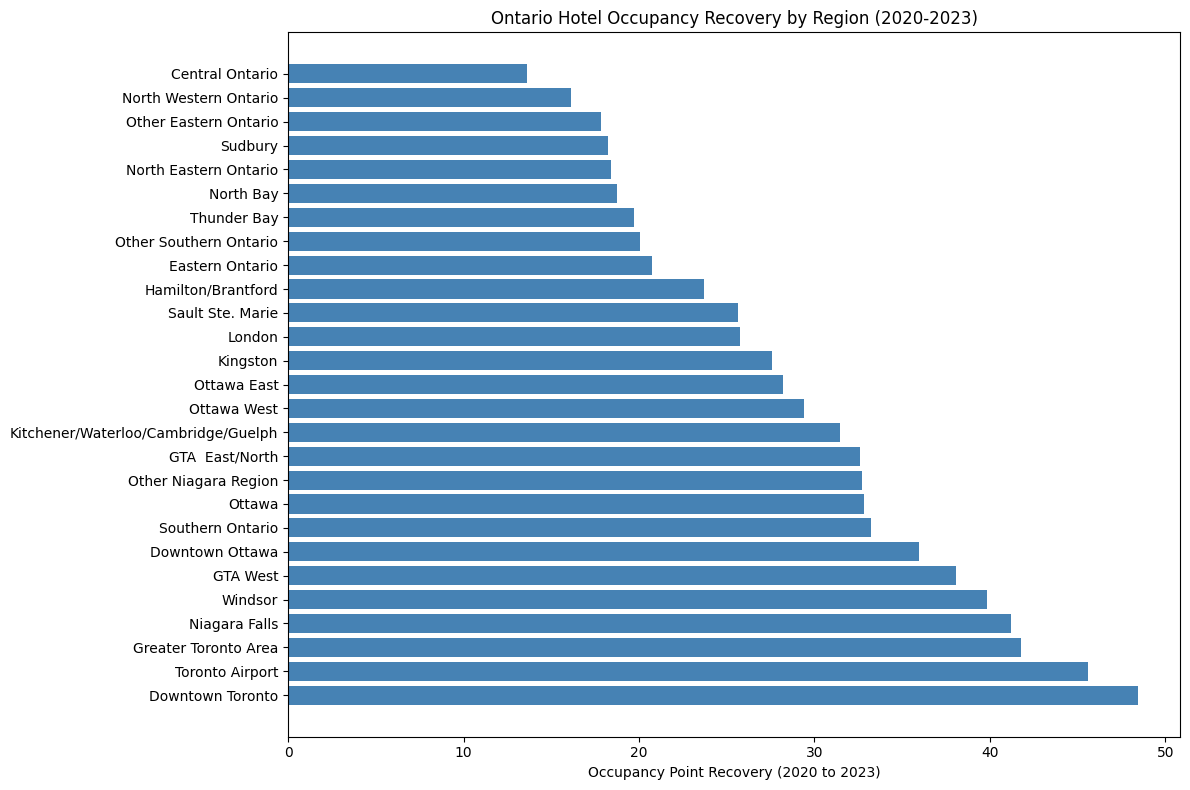

In [59]:
import matplotlib.pyplot as plt

# Remove province-level and NaN rows
recovery_clean = recovery[recovery['Region'] != 'ONTARIO'].dropna(subset=['Occ_Recovery'])

# Plot
plt.figure(figsize=(12, 8))
plt.barh(recovery_clean['Region'], recovery_clean['Occ_Recovery'], color='steelblue')
plt.xlabel('Occupancy Point Recovery (2020 to 2023)')
plt.title('Ontario Hotel Occupancy Recovery by Region (2020-2023)')
plt.tight_layout()
plt.show()

**Analytical Insight:**
* **Downtown Toronto** absorbed the most severe collateral damage in 2020 (relying on decimated corporate and international travel) but exhibited an explosive +48.4 pt recovery arc.
* **Windsor** exhibited a massive delayed surge, primarily linked to the resurgence of trans-border traffic with the Detroit automotive and logistical sectors. 
* Contrastingly, rural or less accessible markets naturally had lower recovery ceilings.

---

### Step 3: Granular Sub-Region Analysis (2023 Performance Indicators)
To isolate actionable local trends and eliminate structural double-counting from aggregated zones (e.g., "Greater Toronto Area", "Eastern Ontario"), we must aggressively filter out macro-summary rows to distill pure sub-market performance.

In [60]:
# Recreate df_subregions
summary_regions = [
    'ONTARIO', 'Greater Toronto Area', 'Eastern Ontario', 
    'Ottawa', 'Southern Ontario', 'Central Ontario', 
    'North Eastern Ontario', 'North Central Ontario', 
    'North Western Ontario'
]

df_subregions = df1[~df1['Region'].isin(summary_regions)].dropna(subset=['Occ_2023'])

# Verify
print(df_subregions['Region'].tolist())

['Downtown Toronto', 'Toronto Airport', 'GTA West', 'GTA  East/North', 'Kingston', 'Other Eastern Ontario', 'Downtown Ottawa', 'Ottawa West', 'Ottawa East', 'London', 'Windsor', 'Kitchener/Waterloo/Cambridge/Guelph', 'Hamilton/Brantford', 'Niagara Falls', 'Other Niagara Region', 'Other Southern Ontario', 'North Bay', 'Sudbury', 'Sault Ste. Marie', 'Thunder Bay']


In [61]:
top5_occ = df_subregions.nlargest(5, 'Occ_2023')[['Region', 'Occ_2023']]
bottom5_occ = df_subregions.nsmallest(5, 'Occ_2023')[['Region', 'Occ_2023']]
top5_adr = df_subregions.nlargest(5, 'ADR_2023')[['Region', 'ADR_2023']]
bottom5_adr = df_subregions.nsmallest(5, 'ADR_2023')[['Region', 'ADR_2023']]

print("Top 5 Occupancy 2023:")
print(top5_occ)
print("\nBottom 5 Occupancy 2023:")
print(bottom5_occ)
print("\nTop 5 ADR 2023:")
print(top5_adr)
print("\nBottom 5 ADR 2023:")
print(bottom5_adr)

Top 5 Occupancy 2023:
              Region  Occ_2023
3    Toronto Airport     79.97
4           GTA West     74.29
5    GTA  East/North     73.45
15           Windsor     72.86
2   Downtown Toronto     70.32

Bottom 5 Occupancy 2023:
                    Region  Occ_2023
20  Other Southern Ontario     53.99
8    Other Eastern Ontario     60.42
23               North Bay     61.56
12             Ottawa East     61.75
24                 Sudbury     61.97

Top 5 ADR 2023:
              Region  ADR_2023
2   Downtown Toronto    323.82
10   Downtown Ottawa    220.22
18     Niagara Falls    207.25
3    Toronto Airport    192.14
28       Thunder Bay    182.88

Bottom 5 ADR 2023:
                    Region  ADR_2023
23               North Bay    132.31
15                 Windsor    136.55
26        Sault Ste. Marie    141.70
8    Other Eastern Ontario    148.54
20  Other Southern Ontario    148.62


### Step 4: Margin Architecture Breakdown (Occupancy vs. Pricing Power)

Does high occupancy equate to aggressive pricing strategies? In many real estate models, scarcity commands premiums. Here, we analyze the microeconomic elasticity between **Volume (Occupancy)** and **Yield (ADR)** to gauge regional pricing architectures.

Correlation between Occupancy and ADR in 2023:
          Occ_2023  ADR_2023
Occ_2023    1.0000    0.3592
ADR_2023    0.3592    1.0000


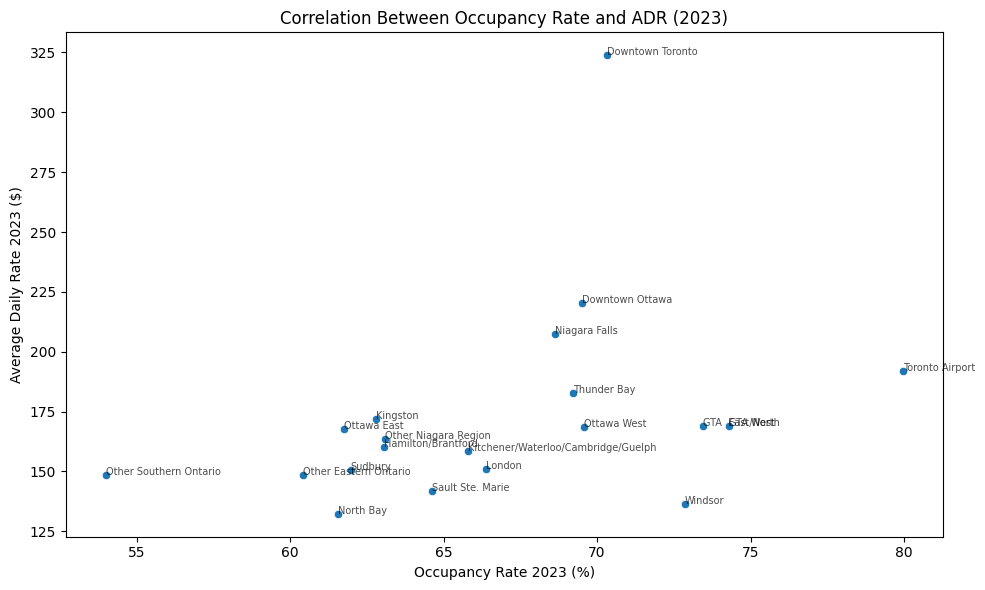

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation
correlation = df_subregions[['Occ_2023', 'ADR_2023']].corr()
print("Correlation between Occupancy and ADR in 2023:")
print(correlation)

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_subregions, x='Occ_2023', y='ADR_2023')

# Add region labels to each point
for i, row in df_subregions.iterrows():
    plt.annotate(row['Region'], (row['Occ_2023'], row['ADR_2023']), 
                fontsize=7, alpha=0.7)

plt.xlabel('Occupancy Rate 2023 (%)')
plt.ylabel('Average Daily Rate 2023 ($)')
plt.title('Correlation Between Occupancy Rate and ADR (2023)')
plt.tight_layout()
plt.show()

**Strategic Conclusion on Margin & Pricing Strategy:**
1. **Low Price / High Volume:** Toronto Airport leverages massive throughput rather than prestige pricing. It commands highest volume but sub-optimal marginal ADR.
2. **High Price / Scaled Volume:** Downtown Toronto exercises absolute monopolistic pricing over luxury/executive stays, driving ADR far beyond expected correlation slopes regardless of missing peak 80%+ occupancy brackets.

---

### Step 5: Revenue Per Available Room (RevPAR)
While Occupancy and ADR provide theoretical margins, **RevPAR** dictates absolute top-line revenue health per unit capital. This fundamentally sizes the TAM (Total Addressable Market) and investment justification strictly across comparable available room supplies.

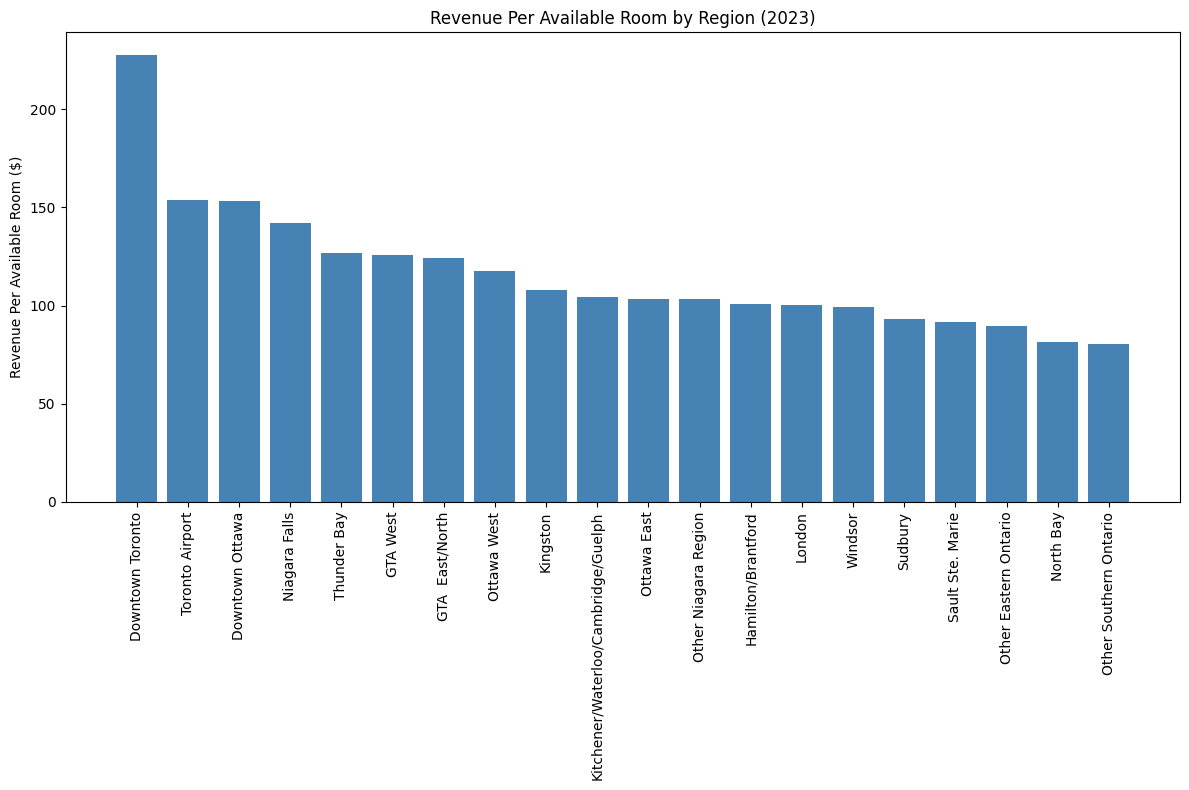

In [63]:
# Sort by RevPAR 2023
revpar_sorted = df_subregions[['Region', 'RevPAR_2023']].sort_values('RevPAR_2023', ascending=False)

plt.figure(figsize=(12, 8))
plt.bar(revpar_sorted['Region'], revpar_sorted['RevPAR_2023'], color='steelblue')
plt.ylabel('Revenue Per Available Room ($)')
plt.title('Revenue Per Available Room by Region (2023)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Bottom-Line Revenue Synthesis:**
* **Asymmetrical Market Concentration:** Downtown Toronto ($227/room) generates a staggering cash flow multiplier over 2.8x the provincial median (approx $80/room). From a capital investment thesis, one room in Downtown Toronto drives the top-line equivalent of roughly 1.5 rooms in the GTA or nearly 3 in North Bay.

---

### Step 6: Temporal Geospatial Heatmap (2020-2023)
By mapping longitudinal performance dynamically across region corridors, we track macro momentum shifts—separating short-term noise from multi-year systemic transitions post-Covid.

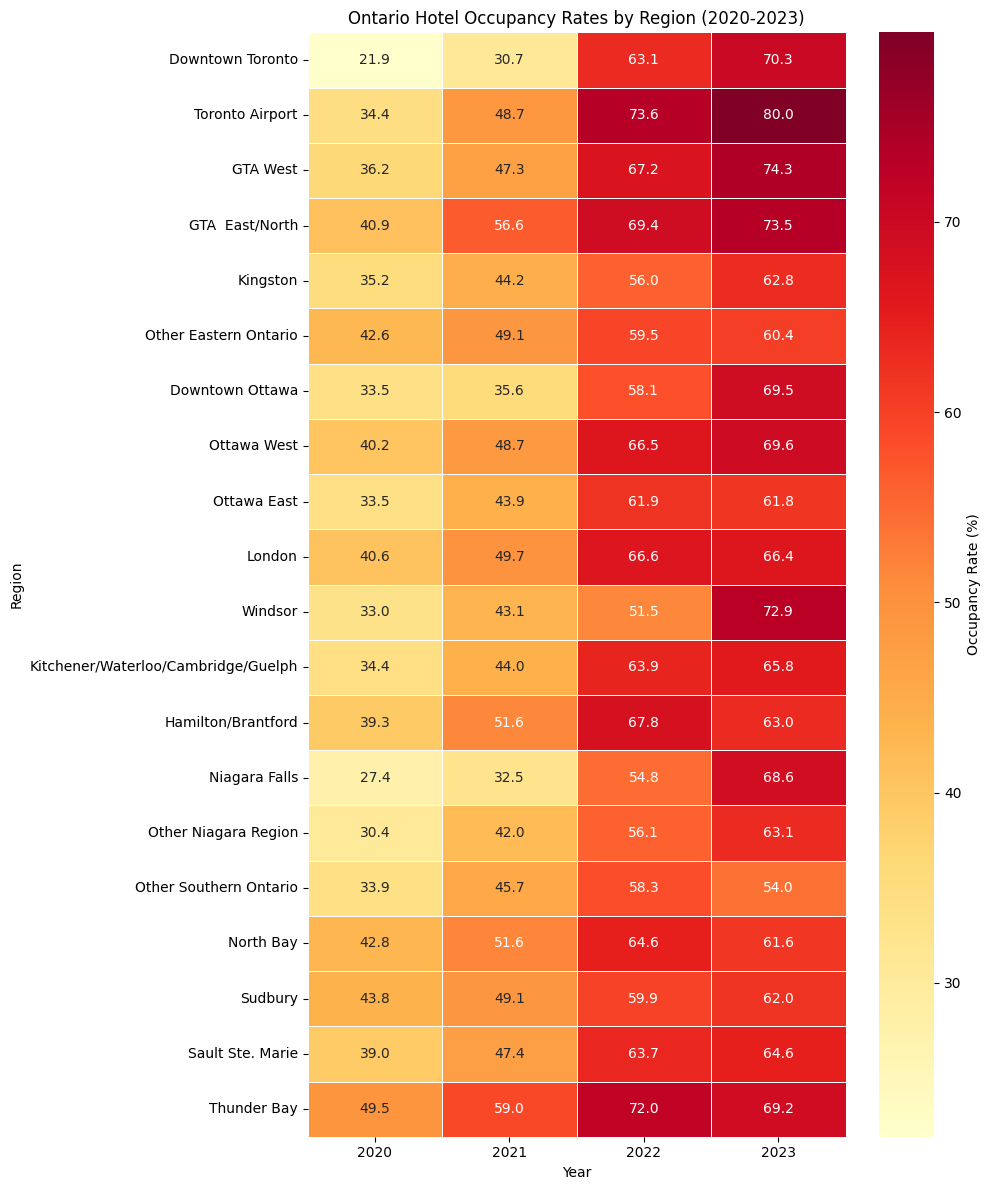

In [ ]:
heatmap_data = df_subregions.set_index('Region')[['Occ_2020', 'Occ_2021', 'Occ_2022', 'Occ_2023']]

plt.figure(figsize=(10, 12))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', 
            linewidths=0.5, cbar_kws={'label': 'Occupancy Rate (%)'})
plt.title('Ontario Hotel Occupancy Rates by Region (2020-2023)')
plt.xlabel('Year')
plt.ylabel('Region')
plt.xticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=['2020', '2021', '2022', '2023'])
plt.tight_layout()
plt.show() 

**Execution & Recovery Thesis (Final Assessment):**
* **The "V-Shape" is Not Universal:** The dramatic structural bounce-back (deep red/orange zones in 2023 vs universally light/yellow 2020) heavily favored international travel gateways (Niagara Falls, Downtown Toronto) and border-zone logistics hubs (Windsor). 
* **Stable Mediocrity vs Risk/Reward:** Northern sectors presented lower initial drawdowns but similarly lower recovery velocity vectors. 

**Forward View:**
To model 2024+ projections, one must analyze secondary factors (interest rates compressing capital expenditure, FX fluctuations pushing American tourism inward, and corporate real estate contraction limiting domestic conference travel). The pure COVID "base-effect" recovery is structurally over; future gains require authentic aggregate demand expansion.